In [2]:
# image transformation using opencv

In [1]:
import cv2
import numpy as np
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
# %matplotlib inline

In [4]:
image = cv2.imread('Self_Driving_Car.jpg')
cv2.imshow('Original Image', image)
cv2.waitKey()
cv2.destroyAllWindows()

In [5]:
height, width = image.shape[:2]

In [6]:
# perform rotation

M_rotation = cv2.getRotationMatrix2D(
    (width/2, height/2), # the center of the image (to rotate around it)
    30, # angle (degrees) 
    0.5) # scale to shrink it down or shrink it up

rotated_image = cv2.warpAffine(
    image, # original image
    M_rotation, # transformation matrix
    (width, height)) # insert size of the output image

cv2.imshow('Rotated', rotated_image)
cv2.waitKey()
cv2.destroyAllWindows()

In [7]:
# perform translation

Translational_Matrix = np.float32([
    [1, 0, 300], # 300 pixels gonna be shifting in the x direction 
    [0, 1, 50] # 50 pixels gonna be shifting in the y direction
]) 

translated_image = cv2.warpAffine(
    image, 
    Translational_Matrix, 
    (width, height)
)

cv2.imshow('Translated Image', translated_image)
cv2.waitKey()
cv2.destroyAllWindows()



In [8]:
# preform resizing

resized_image = cv2.resize(
    image, 
    None, 
    fx=4, fy=4, # scaling factor 
    interpolation = cv2.INTER_CUBIC
) # Try 0.5

cv2.imshow('Resized Image', resized_image) 
cv2.waitKey()
cv2.destroyAllWindows()

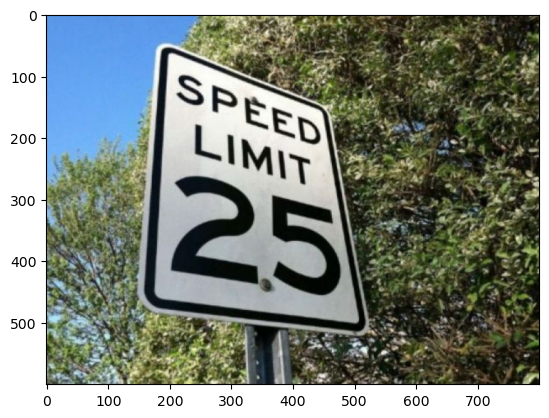

In [2]:
# A VERY IMPORTANT TRANSORMATION: PERSPECTIVE TRANSFORMATION

image = mpimg.imread('Speed_Sign_View_2.jpg')
plt.imshow(image)

In [3]:
height, width = image.shape[:2]

In [4]:
# First entry: top-left,
# Second entry: top-right
# Third: bottom-right
# Fourth: bottom-left

# Cordinates of the 4 corners of the original image
Source_points = np.float32([[200,60], [450,150], [520, 500], [170,470] ])

# Cordinates of the 4 corners of the desired output
Destination_points = np.float32([[0,0], [width,0], [width,height], [0,height]])

In [5]:
# Use the two sets of four points to compute 
# the Perspective Transformation matrix, M    
M = cv2.getPerspectiveTransform(Source_points, Destination_points)
 
warped = cv2.warpPerspective(image, M, (width, height))
 
cv2.imshow('warped Image', warped)
cv2.waitKey()
cv2.destroyAllWindows()

In [6]:
## CODE TO PERFORM CROPPING, DILATION AND EROSION

import cv2
import numpy as np
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
%matplotlib inline

In [7]:
height, width = image.shape[:2]

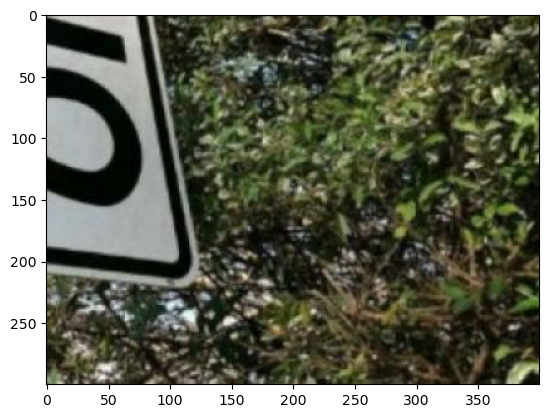

In [9]:
# PERFORM CROPPING


x0 = int(width * 0.5) # width direction
y0 = int(height * 0.5) # height direction

x1 = int(width * 1) # width direction
y1 = int(height * 1) # height direction


Image_cropped = image[y0:y1 , x0:x1]

plt.imshow(Image_cropped)


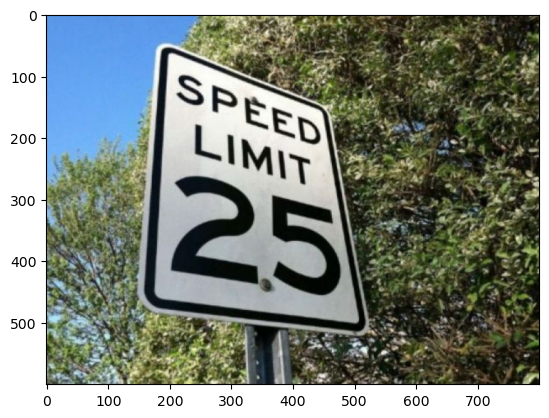

In [10]:
plt.imshow(image)

(-0.5, 799.5, 599.5, -0.5)

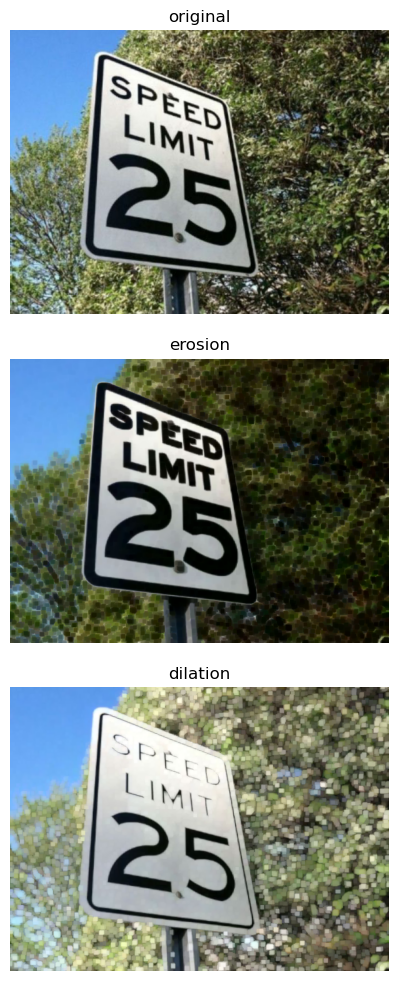

In [13]:
# PERFORM DILATION AND EROSION OPERATIONS

kernel = np.ones((3,3), np.uint8)

image_erosion = cv2.erode(image, kernel, iterations=3) # Try several iterations
image_dilation = cv2.dilate(image, kernel, iterations=3)

figure, axis = plt.subplots(3, 1, figsize=(10, 10))

figure.tight_layout()

axis[0].imshow(image)
axis[0].set_title('original')
axis[0].axis("off")
  
axis[1].imshow(image_erosion)
axis[1].set_title('erosion')
axis[1].axis("off")

axis[2].imshow(image_dilation)
axis[2].set_title('dilation')
axis[2].axis("off")

In [14]:
# .. REGION OF INTEREST MASKING

import cv2
import numpy as np
import matplotlib.image as mpimg
from matplotlib import pyplot as plt
%matplotlib inline

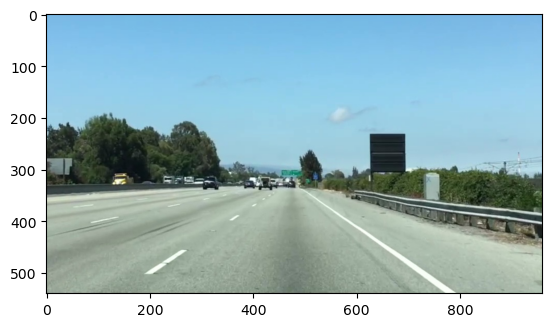

In [16]:
image_color = mpimg.imread('image_lane_c.jpg') # import image as RGB instead of BGR in opencv
plt.imshow(image_color) # we're showing image that is read from matplotlib here, not opencv, so the colors are not inverted

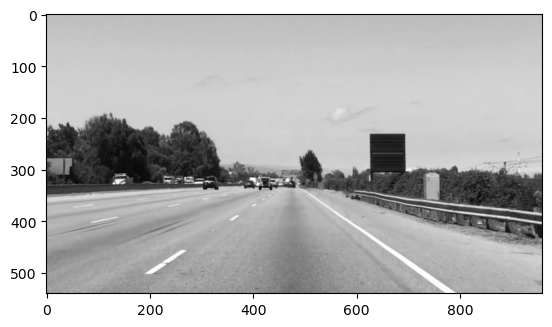

In [17]:
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap = 'gray')

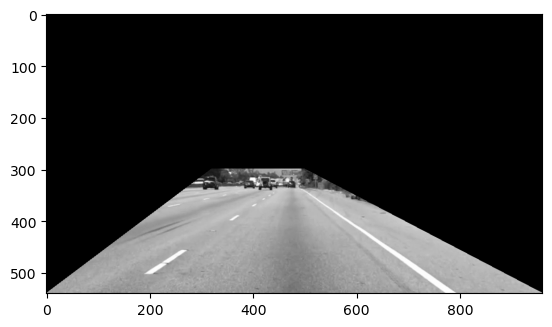

In [18]:
# performing region of interest

# Select points of the region of interest (ROI)
height, width = image_color.shape[:2]

# Poly region
ROI = np.array([[
    (0, height), # bottom left point
    (320, 300), # top left point
    (500, 300), # top right point
    (width, height) # bottom right point
]], dtype=np.int32)    

# define a blank image with all zeros (ie: black) 
blank = np.zeros_like(image_gray)   

# Fill the Region of interest with white color (ie: 255)!
mask = cv2.fillPoly(blank, ROI, 255)
    
# Perform bitwise AND operation to select only the region of interest
masked_image = cv2.bitwise_and(image_gray, mask)

plt.imshow(masked_image, cmap = 'gray')

In [ ]:
# HOUGH TRANSFORMATION

